## Импорты и общие настройки

Сразу сделаем две инженерные привычки:
1) фиксируем seed (воспроизводимость),
2) явно выбираем `device` (CPU/GPU).

In [2]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.7.1+cu118
torchvision: 0.22.1+cu118


In [3]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## Вспомогательные функции (метрики и графики)

Мы будем смотреть минимум:
- `loss`,
- `accuracy`.

И будем строить кривые train/val.

In [4]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [5]:
# Трансформации: ToTensor и Normalize
# EMNIST уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, split="balanced", download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, split="balanced", download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


### Разбиение train/val и DataLoader

Обучающую часть делим на:
- `train`,
- `val`.

Затем создаём `DataLoader`, который выдаёт батчи.


In [6]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)



In [7]:
# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)
print(f"Диапазон значений (правильно для нормализации [-1,1]): [{x_batch.min():.2f}, {x_batch.max():.2f}]")

x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64
Диапазон значений (правильно для нормализации [-1,1]): [-1.00, 1.00]


### Посмотрим на несколько примеров

Важно уметь пощупать данные: убедиться, что загрузка и метки корректны.


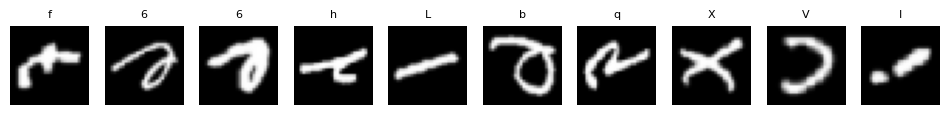

In [8]:
def show_images(loader, n: int = 47) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

## Модель: MLP (nn.Module)

Сделаем класс, который умеет:
- Flatten (784 признака),
- несколько Linear слоёв,
- активации,
- опционально Dropout и BatchNorm.

Важно: **Dropout и BatchNorm ведут себя по-разному в train/eval режиме** –
поэтому мы обязаны в цикле обучения корректно переключать `model.train()` / `model.eval()`.

In [9]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([256, 47])


## Цикл обучения: train/eval + no_grad

В PyTorch обычно пишут две функции:
- `train_one_epoch` – обновляет веса;
- `evaluate` – считает метрики на val/test без градиентов.

Это базовый скелет, который потом расширяется (планировщики LR, клиппинг и т.д.).


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

### EarlyStopping (ранняя остановка)

Идея простая: если качество на validation не улучшается `patience` эпох подряд –
останавливаемся и возвращаемся к лучшим весам.

Это дешёвый и очень полезный инструмент против переобучения.

In [11]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


## Обучение: базовый MLP (baseline) E0

Сначала обучим самый простой вариант (без Dropout и BatchNorm) и посмотрим:
- как падает loss,
- как растёт accuracy,
- есть ли признаки переобучения (разрыв train/val).

In [12]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.4213, acc=0.6035 | val loss=0.9720, acc=0.7094
epoch 02/20 | train loss=0.8029, acc=0.7547 | val loss=0.7262, acc=0.7743
epoch 03/20 | train loss=0.6407, acc=0.7960 | val loss=0.6181, acc=0.8077
epoch 04/20 | train loss=0.5649, acc=0.8165 | val loss=0.5763, acc=0.8146
epoch 05/20 | train loss=0.5161, acc=0.8299 | val loss=0.5281, acc=0.8312
epoch 06/20 | train loss=0.4812, acc=0.8382 | val loss=0.5390, acc=0.8259
epoch 07/20 | train loss=0.4533, acc=0.8458 | val loss=0.5273, acc=0.8293
epoch 08/20 | train loss=0.4328, acc=0.8513 | val loss=0.5012, acc=0.8352
epoch 09/20 | train loss=0.4148, acc=0.8553 | val loss=0.4840, acc=0.8413
epoch 10/20 | train loss=0.3945, acc=0.8618 | val loss=0.4972, acc=0.8394
epoch 11/20 | train loss=0.3808, acc=0.8648 | val loss=0.4826, acc=0.8441
epoch 12/20 | train loss=0.3680, acc=0.8688 | val loss=0.4933, acc=0.8381
epoch 13/20 | train loss=0.3578, acc=0.8714 | val loss=0.4923, acc=0.8378
epoch 14/20 | train loss=0.3439, acc=0

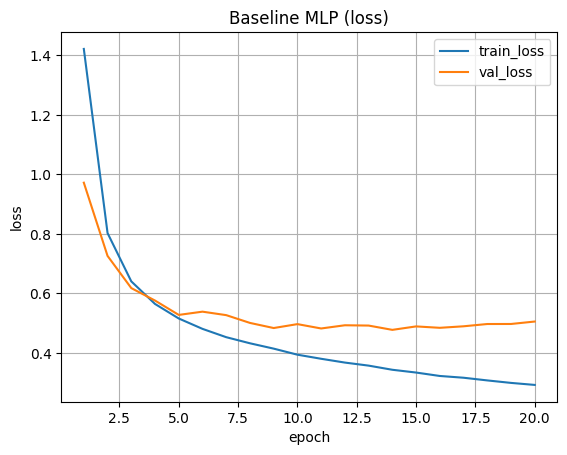

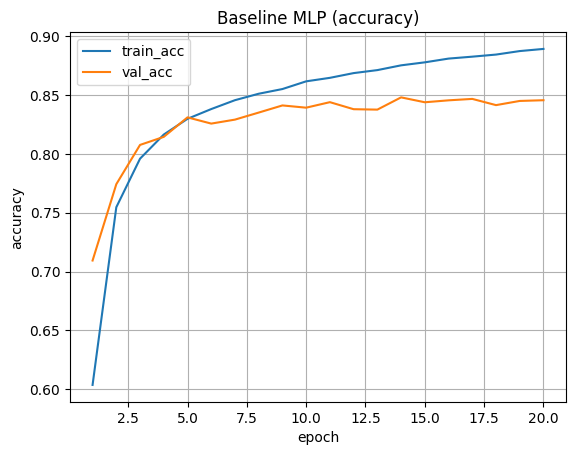

In [13]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [14]:
# Финальная проверка на test
test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Baseline test: loss=0.5448, acc=0.8333


# E1 (глубже/шире)

epoch 01/20 | train loss=1.3160, acc=0.6205 | val loss=0.7937, acc=0.7557
epoch 02/20 | train loss=0.6872, acc=0.7795 | val loss=0.6398, acc=0.7990
epoch 03/20 | train loss=0.5598, acc=0.8142 | val loss=0.5378, acc=0.8252
epoch 04/20 | train loss=0.4909, acc=0.8343 | val loss=0.5272, acc=0.8297
epoch 05/20 | train loss=0.4469, acc=0.8451 | val loss=0.4938, acc=0.8305
epoch 06/20 | train loss=0.4133, acc=0.8538 | val loss=0.4777, acc=0.8420
epoch 07/20 | train loss=0.3858, acc=0.8623 | val loss=0.4764, acc=0.8497
epoch 08/20 | train loss=0.3646, acc=0.8675 | val loss=0.4725, acc=0.8431
epoch 09/20 | train loss=0.3439, acc=0.8728 | val loss=0.4682, acc=0.8457
epoch 10/20 | train loss=0.3258, acc=0.8796 | val loss=0.4647, acc=0.8472
epoch 11/20 | train loss=0.3136, acc=0.8815 | val loss=0.4767, acc=0.8500
epoch 12/20 | train loss=0.2974, acc=0.8855 | val loss=0.4674, acc=0.8500
epoch 13/20 | train loss=0.2846, acc=0.8911 | val loss=0.4647, acc=0.8511
epoch 14/20 | train loss=0.2746, acc=0

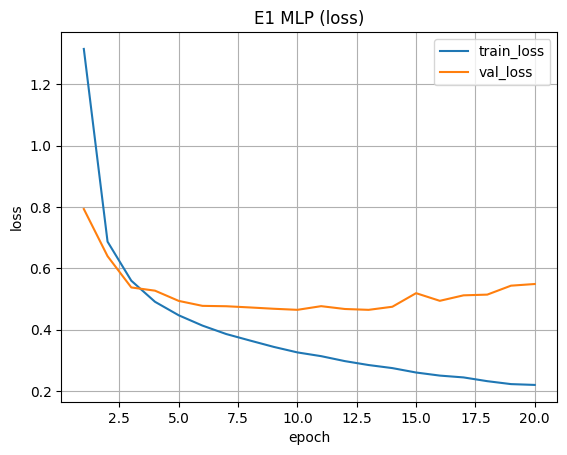

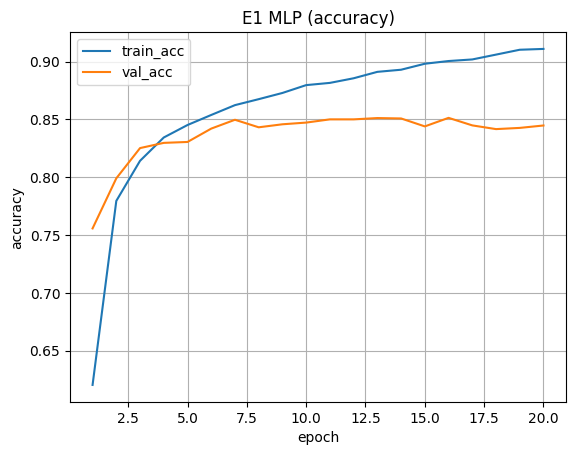

E1 test: loss=0.5684, acc=0.8377


In [15]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
model_e1 = MLP(
    hidden_dims=(512, 256, 128),  # Больше нейронов и глубже чем baseline (256, 128)
    dropout_p=0.0,                 # Без Dropout
    use_batchnorm=False,            # Без BatchNorm
    activation='relu'
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e1.parameters(), lr=1e-3)

history_model_e1 = fit(
    model_e1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_model_e1, title="E1 MLP")
test_loss, test_acc = evaluate(model_e1, test_loader, criterion, device)
print(f"E1 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Эксперимент E2: Dropout

Dropout случайно зануляет часть нейронов на обучении.
Эффект:
- модель хуже запоминает шум или частности,
- часто лучше обобщает на validation.

Важно: Dropout активен только в `model.train()`; в `model.eval()` он выключен.

epoch 01/20 | train loss=1.6880, acc=0.5113 | val loss=0.8577, acc=0.7360
epoch 02/20 | train loss=0.9754, acc=0.6959 | val loss=0.6808, acc=0.7866
epoch 03/20 | train loss=0.8313, acc=0.7366 | val loss=0.5996, acc=0.8095
epoch 04/20 | train loss=0.7625, acc=0.7574 | val loss=0.5672, acc=0.8153
epoch 05/20 | train loss=0.7140, acc=0.7688 | val loss=0.5348, acc=0.8275
epoch 06/20 | train loss=0.6820, acc=0.7780 | val loss=0.5144, acc=0.8317
epoch 07/20 | train loss=0.6582, acc=0.7848 | val loss=0.4966, acc=0.8359
epoch 08/20 | train loss=0.6345, acc=0.7922 | val loss=0.4879, acc=0.8363
epoch 09/20 | train loss=0.6225, acc=0.7937 | val loss=0.4829, acc=0.8404
epoch 10/20 | train loss=0.6062, acc=0.7995 | val loss=0.4783, acc=0.8404
epoch 11/20 | train loss=0.5942, acc=0.8023 | val loss=0.4638, acc=0.8420
epoch 12/20 | train loss=0.5837, acc=0.8046 | val loss=0.4678, acc=0.8416
epoch 13/20 | train loss=0.5749, acc=0.8079 | val loss=0.4554, acc=0.8451
epoch 14/20 | train loss=0.5629, acc=0

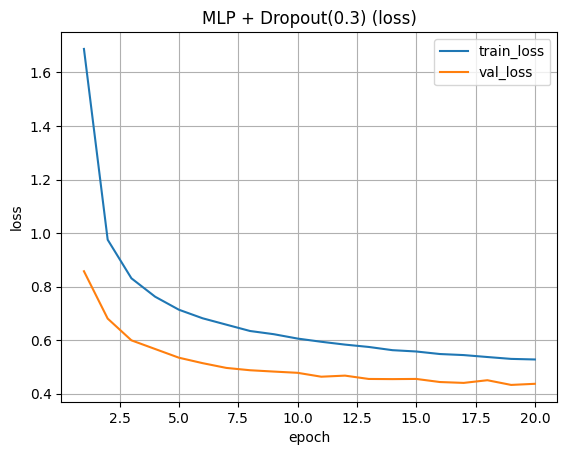

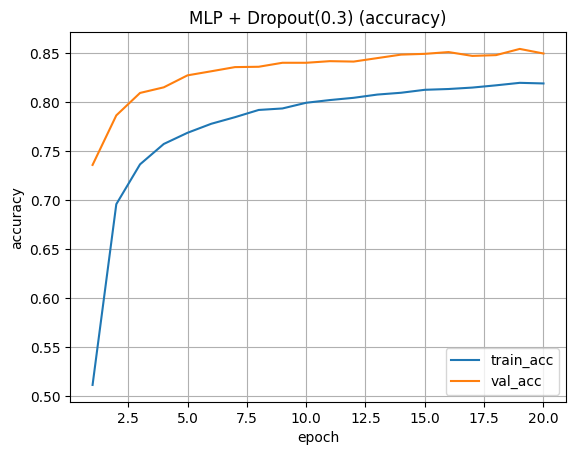

Dropout test: loss=0.4592, acc=0.8424


In [16]:
set_seed(42)
dropout_model = MLP(hidden_dims=(512, 256, 128),
                     dropout_p=0.3, 
                     use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")
best_e2_acc = max(history_dropout["val_acc"])#выбираем лучший для е4

## Эксперимент E3: BatchNorm

BatchNorm нормализует активации внутри сети.
Обычно даёт:
- более стабильное обучение,
- иногда выше итоговое качество,
- меньшую чувствительность к инициализации и масштабам.

Важно: BatchNorm использует разные статистики в train/eval режиме, поэтому переключение режимов критично.

epoch 01/20 | train loss=0.9478, acc=0.7489 | val loss=0.5740, acc=0.8168
epoch 02/20 | train loss=0.4735, acc=0.8389 | val loss=0.4806, acc=0.8399
epoch 03/20 | train loss=0.3934, acc=0.8616 | val loss=0.4451, acc=0.8509
epoch 04/20 | train loss=0.3484, acc=0.8745 | val loss=0.4304, acc=0.8521
epoch 05/20 | train loss=0.3112, acc=0.8841 | val loss=0.4424, acc=0.8489
epoch 06/20 | train loss=0.2861, acc=0.8911 | val loss=0.4258, acc=0.8537
epoch 07/20 | train loss=0.2635, acc=0.8993 | val loss=0.4400, acc=0.8548
epoch 08/20 | train loss=0.2457, acc=0.9043 | val loss=0.4355, acc=0.8568
epoch 09/20 | train loss=0.2266, acc=0.9104 | val loss=0.4377, acc=0.8601
epoch 10/20 | train loss=0.2131, acc=0.9151 | val loss=0.4609, acc=0.8542
epoch 11/20 | train loss=0.2028, acc=0.9174 | val loss=0.4486, acc=0.8589
epoch 12/20 | train loss=0.1936, acc=0.9208 | val loss=0.4711, acc=0.8536
epoch 13/20 | train loss=0.1805, acc=0.9257 | val loss=0.4598, acc=0.8583
epoch 14/20 | train loss=0.1736, acc=0

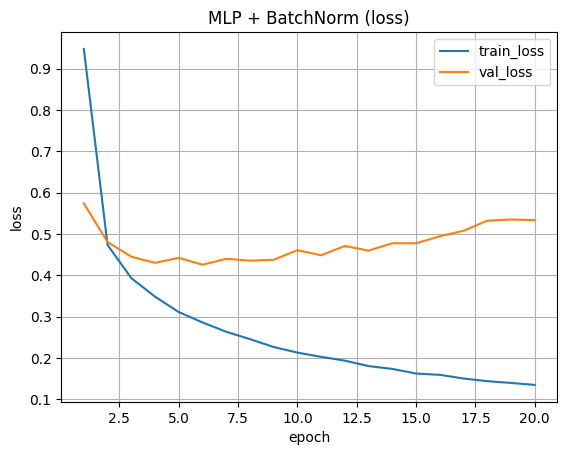

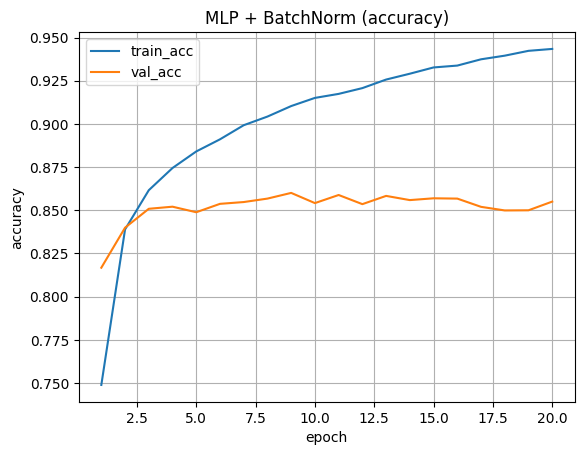

BatchNorm test: loss=0.5996, acc=0.8472


In [17]:
set_seed(42)
bn_model = MLP(hidden_dims=(512, 256, 128),
                dropout_p=0.0, 
                use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")
best_e3_acc = max(history_bn["val_acc"])#выбираем лучший для е4

## Эксперимент E4: Dropout, BatchNorm, EarlyStopping

Теперь соберём практичный вариант:
- Dropout с BatchNorm,
- и добавим EarlyStopping по val accuracy.

Идея: не тратить эпохи впустую и не уехать в переобучение.

In [18]:
#выбираепм лучший из e2,e3
if best_e2_acc > best_e3_acc:
    print("Лучший: E2 (Dropout)")
    best_config = {
        "hidden_dims": (512, 256, 128),  
        "dropout_p": 0.3,                 
        "use_batchnorm": False              
    }
else:
    print("Лучший: E3 (BatchNorm)")
    best_config = {
        "hidden_dims": (512, 256, 128),  
        "dropout_p": 0.0,                   
        "use_batchnorm": True               
    }

Лучший: E3 (BatchNorm)


epoch 01/50 | train loss=0.9478, acc=0.7489 | val loss=0.5740, acc=0.8168
epoch 02/50 | train loss=0.4735, acc=0.8389 | val loss=0.4806, acc=0.8399
epoch 03/50 | train loss=0.3934, acc=0.8616 | val loss=0.4451, acc=0.8509
epoch 04/50 | train loss=0.3484, acc=0.8745 | val loss=0.4304, acc=0.8521
epoch 05/50 | train loss=0.3112, acc=0.8841 | val loss=0.4424, acc=0.8489
epoch 06/50 | train loss=0.2861, acc=0.8911 | val loss=0.4258, acc=0.8537
epoch 07/50 | train loss=0.2635, acc=0.8993 | val loss=0.4400, acc=0.8548
epoch 08/50 | train loss=0.2457, acc=0.9043 | val loss=0.4355, acc=0.8568
epoch 09/50 | train loss=0.2266, acc=0.9104 | val loss=0.4377, acc=0.8601
epoch 10/50 | train loss=0.2131, acc=0.9151 | val loss=0.4609, acc=0.8542
epoch 11/50 | train loss=0.2028, acc=0.9174 | val loss=0.4486, acc=0.8589
epoch 12/50 | train loss=0.1936, acc=0.9208 | val loss=0.4711, acc=0.8536
epoch 13/50 | train loss=0.1805, acc=0.9257 | val loss=0.4598, acc=0.8583
EarlyStopping: остановка на эпохе 13. 

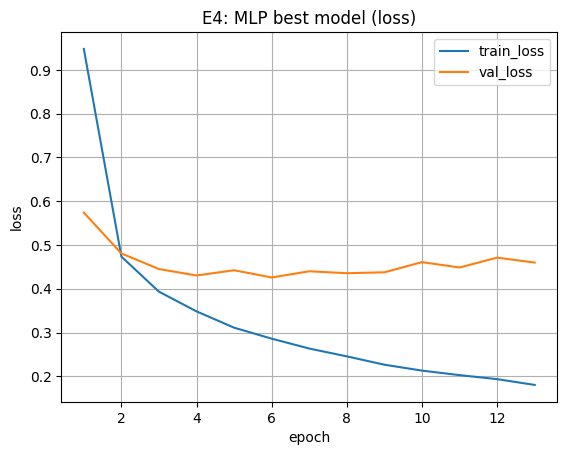

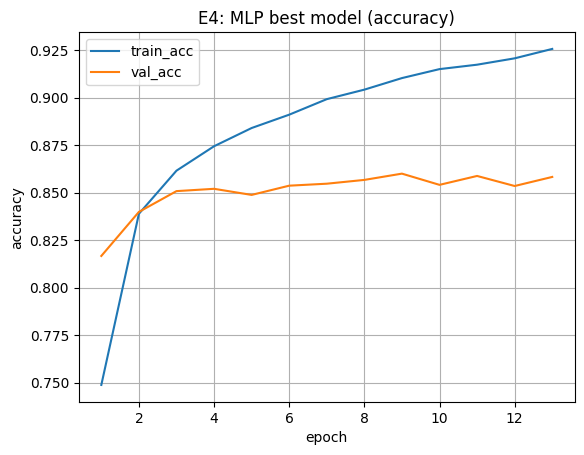

Combo test: loss=0.4693, acc=0.8495


In [19]:
set_seed(42)
combo_model = MLP(
    hidden_dims=best_config["hidden_dims"],
    dropout_p=best_config["dropout_p"],
    use_batchnorm=best_config["use_batchnorm"]
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="E4: MLP best model")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Часть B (S09): LR, оптимизаторы, weight decay

O1 (LR слишком большой - 1e-1)

In [20]:
set_seed(42)
model_o1= MLP(
    hidden_dims=best_config["hidden_dims"],
    dropout_p=best_config["dropout_p"],
    use_batchnorm=best_config["use_batchnorm"]
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_o1.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,  
    verbose=True
)



epoch 01/6 | train loss=0.9478, acc=0.7489 | val loss=0.5740, acc=0.8168
epoch 02/6 | train loss=0.4735, acc=0.8389 | val loss=0.4806, acc=0.8399
epoch 03/6 | train loss=0.3934, acc=0.8616 | val loss=0.4451, acc=0.8509
epoch 04/6 | train loss=0.3484, acc=0.8745 | val loss=0.4304, acc=0.8521
epoch 05/6 | train loss=0.3112, acc=0.8841 | val loss=0.4424, acc=0.8489
epoch 06/6 | train loss=0.2861, acc=0.8911 | val loss=0.4258, acc=0.8537


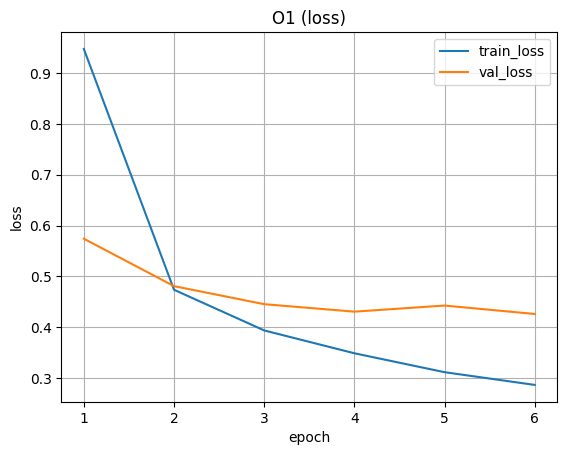

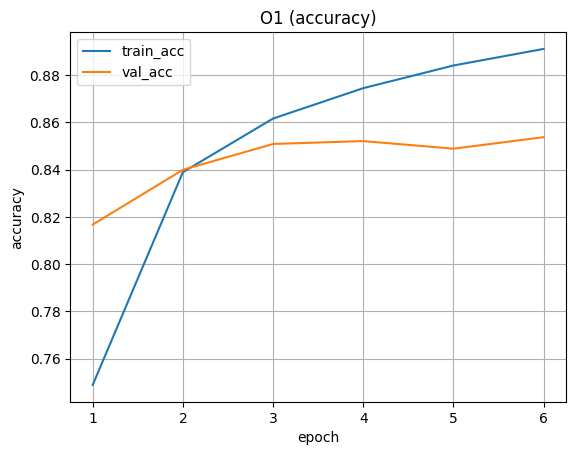

O1 test: loss=0.4433, acc=0.8529


In [21]:
plot_history(history_o1, title="O1")
test_loss, test_acc = evaluate(model_o1, test_loader, criterion, device)
print(f"O1 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

O2 (LR слишком маленький - 1e-5)

In [22]:
set_seed(42)
model_o2 = MLP(
    hidden_dims=best_config["hidden_dims"],
    dropout_p=best_config["dropout_p"],
    use_batchnorm=best_config["use_batchnorm"]
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,  
    verbose=True
)


epoch 01/6 | train loss=3.4439, acc=0.1978 | val loss=3.0743, acc=0.3771
epoch 02/6 | train loss=2.8663, acc=0.4593 | val loss=2.6810, acc=0.5191
epoch 03/6 | train loss=2.5404, acc=0.5564 | val loss=2.4118, acc=0.5839
epoch 04/6 | train loss=2.2979, acc=0.6067 | val loss=2.2014, acc=0.6260
epoch 05/6 | train loss=2.0971, acc=0.6414 | val loss=2.0111, acc=0.6491
epoch 06/6 | train loss=1.9245, acc=0.6672 | val loss=1.8538, acc=0.6736


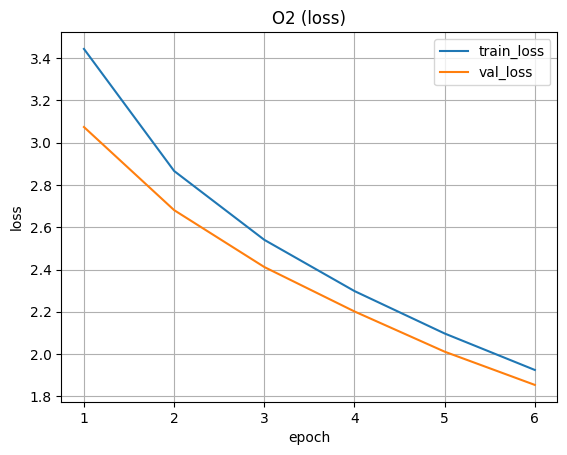

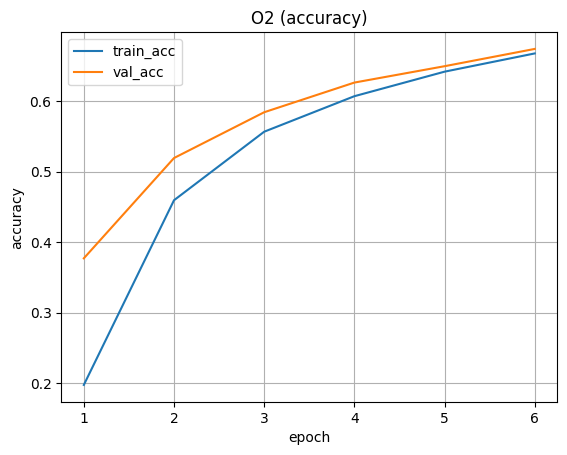

O2 test: loss=1.8567, acc=0.6708


In [23]:
plot_history(history_o2, title="O2")
test_loss, test_acc = evaluate(model_o2, test_loader, criterion, device)
print(f"O2 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

O3 (SGD + momentum + weight decay)

In [24]:
set_seed(42)
model_o3 = MLP(
    hidden_dims=best_config["hidden_dims"],
    dropout_p=best_config["dropout_p"],
    use_batchnorm=best_config["use_batchnorm"]
).to(device)

criterion = nn.CrossEntropyLoss()
# SGD с momentum и weight decay
optimizer = optim.SGD(
    model_o3.parameters(), 
    lr=1e-3,           # разумный LR (как в E4)
    momentum=0.9,      # momentum
    weight_decay=1e-4  # weight decay (L2 регуляризация)
)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o3 = fit(
    model_o3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=10,  
    early_stopping=es,
    verbose=True
)



epoch 01/10 | train loss=2.6912, acc=0.4493 | val loss=1.9654, acc=0.6130
epoch 02/10 | train loss=1.5993, acc=0.6635 | val loss=1.3206, acc=0.7023
epoch 03/10 | train loss=1.1429, acc=0.7289 | val loss=1.0111, acc=0.7492
epoch 04/10 | train loss=0.9092, acc=0.7665 | val loss=0.8452, acc=0.7792
epoch 05/10 | train loss=0.7698, acc=0.7921 | val loss=0.7432, acc=0.7957
epoch 06/10 | train loss=0.6760, acc=0.8112 | val loss=0.6739, acc=0.8108
epoch 07/10 | train loss=0.6094, acc=0.8250 | val loss=0.6267, acc=0.8214
epoch 08/10 | train loss=0.5592, acc=0.8361 | val loss=0.5882, acc=0.8286
epoch 09/10 | train loss=0.5185, acc=0.8463 | val loss=0.5626, acc=0.8337
epoch 10/10 | train loss=0.4850, acc=0.8537 | val loss=0.5412, acc=0.8368


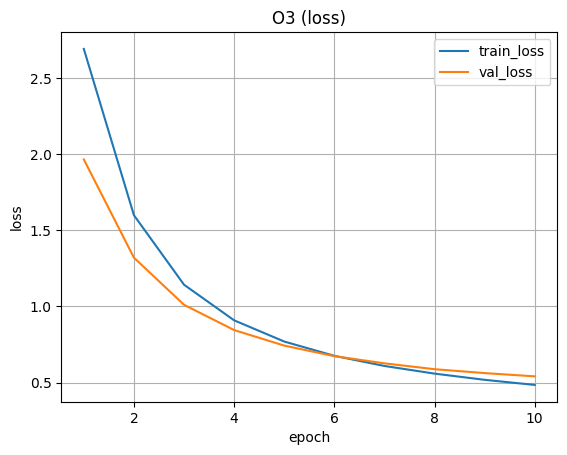

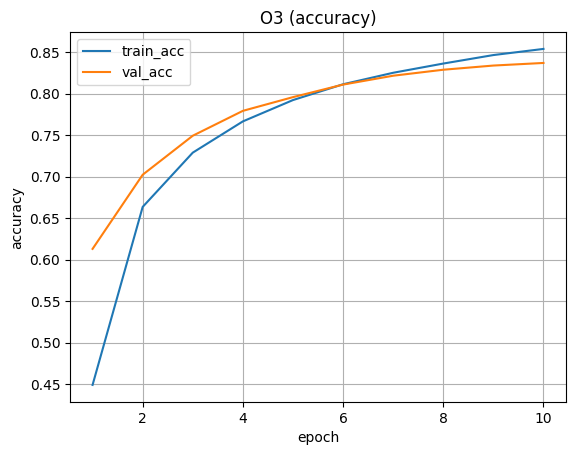

o3 test: loss=0.5607, acc=0.8272


In [25]:
plot_history(history_o3, title="O3")
test_loss, test_acc = evaluate(model_o3, test_loader, criterion, device)
print(f"o3 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Мини-сравнение результатов

Сведём итог по test accuracy (для ориентира).


In [26]:
artifacts_dir = "artifacts"
figures_dir = artifacts_dir + "/figures"

In [39]:
# 1. Сохраняем таблицу результатов runs.csv
results_data = []

# Данные для каждого эксперимента
experiments = [
    # E1_deeper
    {
        "experiment_id": "E1",
        "history": history_model_e1,
        "model": model_e1,
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": "",
        "weight_decay": 0,
        "config": {"hidden_dims": (512, 256, 128), "dropout": 0.0, "batchnorm": False, "activation": "relu"}
    },
    # E2_dropout
    {
        "experiment_id": "E2",
        "history": history_dropout,
        "model": dropout_model,
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": "",
        "weight_decay": 0,
        "config": {"hidden_dims": (512, 256, 128), "dropout": 0.3, "batchnorm": False, "activation": "relu"}
    },
    # E3_batchnorm
    {
        "experiment_id": "E3",
        "history": history_bn,
        "model": bn_model,
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": "",
        "weight_decay": 0,
        "config": {"hidden_dims": (512, 256, 128), "dropout": 0.0, "batchnorm": True, "activation": "relu"}
    },
    # E4_best_choice
    {
        "experiment_id": "E4",
        "history": history_combo,
        "model": combo_model,
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": "",
        "weight_decay": 0,
        "config": {"hidden_dims": best_config["hidden_dims"], "dropout": best_config["dropout_p"], "batchnorm": best_config["use_batchnorm"], "activation": "relu"}
    }  
]

experiments.extend([
    {
        "experiment_id": "O1",
        "history": history_o1,
        "model": model_o1,
        "optimizer": "Adam",
        "lr": 1e-1,
        "momentum": "",
        "weight_decay": 0,
        "config": {"hidden_dims": best_config["hidden_dims"], "dropout": best_config["dropout_p"], "batchnorm": best_config["use_batchnorm"], "activation": "relu"}
    
    },
    {
        "experiment_id": "O2",
        "history": history_o2,
        "model": model_o2,
        "optimizer": "Adam",
        "lr": 1e-5,
        "momentum": "",
        "weight_decay": 0,
        "config": {"hidden_dims": best_config["hidden_dims"], "dropout": best_config["dropout_p"], "batchnorm": best_config["use_batchnorm"], "activation": "relu"}
    },
    {
        "experiment_id": "O3",
        "history": history_o3,
        "model": model_o3,
        "optimizer": "SGD",
        "lr": 1e-3,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "config": {"hidden_dims": best_config["hidden_dims"], "dropout": best_config["dropout_p"], "batchnorm": best_config["use_batchnorm"], "activation": "relu"}
    
    }
])

# Формируем данные для таблицы
for exp in experiments:
    best_val_acc = max(exp["history"]["val_acc"])
    best_val_loss = exp["history"]["val_loss"][exp["history"]["val_acc"].index(best_val_acc)]
    best_epoch = exp["history"]["val_acc"].index(best_val_acc) + 1
    
    # Формируем model_summary
    config = exp["config"]
    bn_str = "bn," if config["batchnorm"] else ""
    dropout_str = f"dropout {config['dropout']}," if config["dropout"] > 0 else ""
    model_summary = f"MLP,{config['hidden_dims']},{dropout_str}{bn_str}ReLU"
    
    results_data.append({
        "experiment_id": exp["experiment_id"],
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": model_summary,
        "optimizer": exp["optimizer"],
        "lr": exp["lr"],
        "momentum": exp["momentum"],
        "weight_decay": exp["weight_decay"],
        "epochs_trained": len(exp["history"]["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch
    })

# Сохраняем
df_results = pd.DataFrame(results_data)
df_results.to_csv(artifacts_dir + "/runs.csv", index=False)
print("Сохранен runs.csv")

print("ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print(df_results.to_string(index=False))

Сохранен runs.csv
ТАБЛИЦА РЕЗУЛЬТАТОВ:
experiment_id dataset  seed                        model_summary optimizer      lr momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss  best_epoch
           E1  EMNIST    42             MLP,(512, 256, 128),ReLU      Adam 0.00100                 0.0000              20           0.851302       0.494138          16
           E2  EMNIST    42 MLP,(512, 256, 128),dropout 0.3,ReLU      Adam 0.00100                 0.0000              20           0.854514       0.433072          19
           E3  EMNIST    42          MLP,(512, 256, 128),bn,ReLU      Adam 0.00100                 0.0000              20           0.860069       0.437663           9
           E4  EMNIST    42          MLP,[512, 256, 128],bn,ReLU      Adam 0.00100                 0.0000              13           0.860069       0.437663           9
           O1  EMNIST    42          MLP,[512, 256, 128],bn,ReLU      Adam 0.10000                 0.0000               6

## Выводы

1) PyTorch-минимум для нейросети – это: `Dataset/DataLoader`, `nn.Module`, `loss`, `optimizer`, правильные режимы `train/eval`.
2) Переобучение видно по разрыву train/val и росту val loss при падении train loss.
3) Dropout, BatchNorm, EarlyStopping – это практичные базовые инструменты, которые часто дают выигрыш.
4) Активации и инициализация реально влияют на динамику обучения (поэтому важно понимать, что вы включаете в модель).

In [33]:
# Просто сохраняем E4
best_model = combo_model
best_exp_name = "E4"
torch.save(best_model.state_dict(), artifacts_dir + "/best_model.pt")

print(f" Сохранен best_model.pt из эксперимента E4")

 Сохранен best_model.pt из эксперимента E4


In [34]:
# Получаем конфигурацию лучшей модели из experiments
best_exp_config = None
for exp in experiments:
    if exp["experiment_id"] == best_exp_name:
        best_exp_config = exp
        break

if best_exp_config:
    # Находим лучшую эпоху для этой модели
    best_val_acc = max(best_exp_config["history"]["val_acc"])
    best_epoch = best_exp_config["history"]["val_acc"].index(best_val_acc) + 1
    
    best_config = {
        # Идентификация
        "experiment_id": best_exp_name,
        "dataset": "EMNIST",
        "seed": 42,
        
        # Архитектура модели
        "hidden_dims": list(best_exp_config["config"]["hidden_dims"]),
        "dropout_p": best_exp_config["config"]["dropout"],
        "use_batchnorm": best_exp_config["config"]["batchnorm"],
        "activation": best_exp_config["config"]["activation"],
        
        # Параметры оптимизации
        "optimizer": best_exp_config["optimizer"],
        "learning_rate": best_exp_config["lr"],
        "momentum": best_exp_config["momentum"] if best_exp_config["momentum"] not in ("", None) else None,
        "weight_decay": best_exp_config["weight_decay"],
        
        # Параметры обучения
        "batch_size": BATCH_SIZE,  # Убедитесь, что эта переменная определена
        "max_epochs": len(best_exp_config["history"]["train_loss"]),  # Сколько всего обучали
        "early_stopping_patience": 4 if "E4" in best_exp_name else None,
        
        # Результаты
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_exp_config["history"]["val_loss"][best_epoch - 1]
    }
    
    # Сохраняем в JSON
    with open(artifacts_dir + "/best_config.json", "w") as f:
        json.dump(best_config, f, indent=2, ensure_ascii=False)
    print(f"Сохранен best_config.json для эксперимента {best_exp_name}")
    
    # Для наглядности выведем содержимое
    print("\nСодержимое best_config.json:")
    print(json.dumps(best_config, indent=2, ensure_ascii=False))
    
else:
    print(f"Ошибка: конфиг для {best_exp_name} не найден")
    print("Доступные эксперименты:", [exp["experiment_id"] for exp in experiments])

Сохранен best_config.json для эксперимента E4

Содержимое best_config.json:
{
  "experiment_id": "E4",
  "dataset": "EMNIST",
  "seed": 42,
  "hidden_dims": [
    512,
    256,
    128
  ],
  "dropout_p": 0.0,
  "use_batchnorm": true,
  "activation": "relu",
  "optimizer": "Adam",
  "learning_rate": 0.001,
  "momentum": null,
  "weight_decay": 0,
  "batch_size": 256,
  "max_epochs": 13,
  "early_stopping_patience": 4,
  "best_epoch": 9,
  "best_val_accuracy": 0.8600694444444444,
  "best_val_loss": 0.4376634018288718
}


СОЗДАНИЕ ГРАФИКА ДЛЯ ЛУЧШЕЙ МОДЕЛИ (E4)
Лучшая эпоха: 9, val_acc: 0.8601


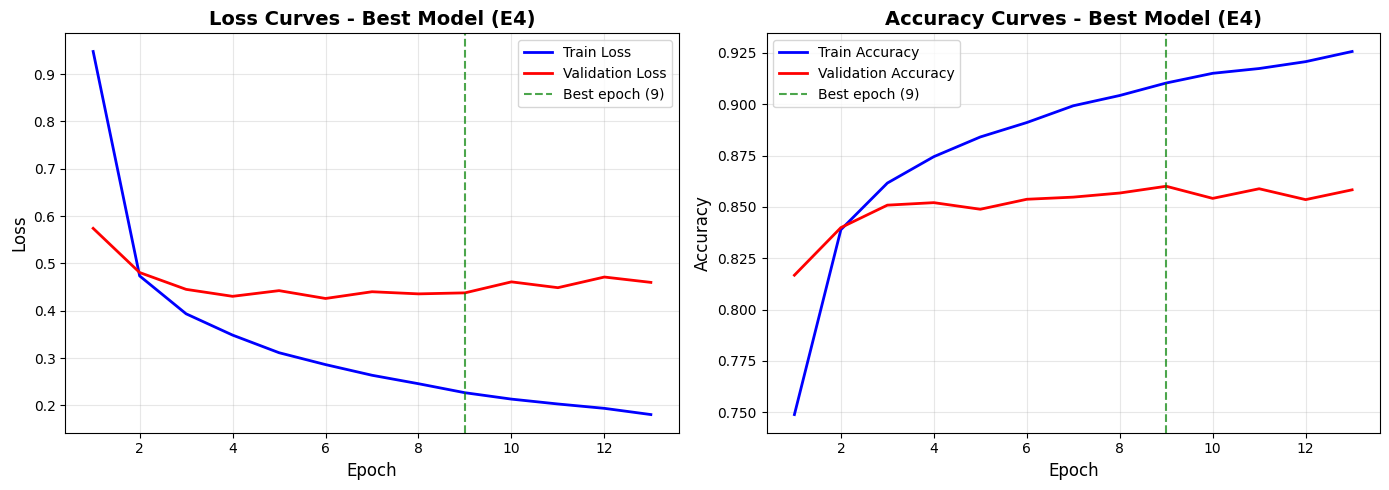


Финальные метрики лучшей модели (E4):
  Train loss: 0.1805
  Val loss: 0.4598
  Train accuracy: 0.9257
  Val accuracy: 0.8583
  Лучшая val accuracy: 0.8601 (эпоха 9)


In [30]:
# === График для лучшей модели (E4) ===
print("СОЗДАНИЕ ГРАФИКА ДЛЯ ЛУЧШЕЙ МОДЕЛИ (E4)")
# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Данные для лучшей модели (E4)
# Используем history_combo (или history_e4, в зависимости от вашей переменной)
best_history = history_combo  # или history_e4, если переименовали

epochs = range(1, len(best_history["train_loss"]) + 1)
best_epoch = None

# Находим лучшую эпоху по validation accuracy
if "val_acc" in best_history:
    best_val_acc = max(best_history["val_acc"])
    best_epoch = best_history["val_acc"].index(best_val_acc) + 1
    print(f"Лучшая эпоха: {best_epoch}, val_acc: {best_val_acc:.4f}")

# График 1: Loss
ax1.plot(epochs, best_history["train_loss"], 'b-', linewidth=2, label='Train Loss')
ax1.plot(epochs, best_history["val_loss"], 'r-', linewidth=2, label='Validation Loss')
if best_epoch:
    ax1.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, 
                label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss Curves - Best Model (E4)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# График 2: Accuracy
ax2.plot(epochs, best_history["train_acc"], 'b-', linewidth=2, label='Train Accuracy')
ax2.plot(epochs, best_history["val_acc"], 'r-', linewidth=2, label='Validation Accuracy')
if best_epoch:
    ax2.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7,
                label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy Curves - Best Model (E4)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Сохраняем график
plt.savefig(f"{figures_dir}/curves_best.png", dpi=150, bbox_inches='tight')
plt.show()

# Выведем финальные метрики
print(f"\nФинальные метрики лучшей модели (E4):")
print(f"  Train loss: {best_history['train_loss'][-1]:.4f}")
print(f"  Val loss: {best_history['val_loss'][-1]:.4f}")
print(f"  Train accuracy: {best_history['train_acc'][-1]:.4f}")
print(f"  Val accuracy: {best_history['val_acc'][-1]:.4f}")
if best_epoch:
    print(f"  Лучшая val accuracy: {best_val_acc:.4f} (эпоха {best_epoch})")

ГРАФИК ДИАГНОСТИКИ LEARNING RATE (O1 vs O2)


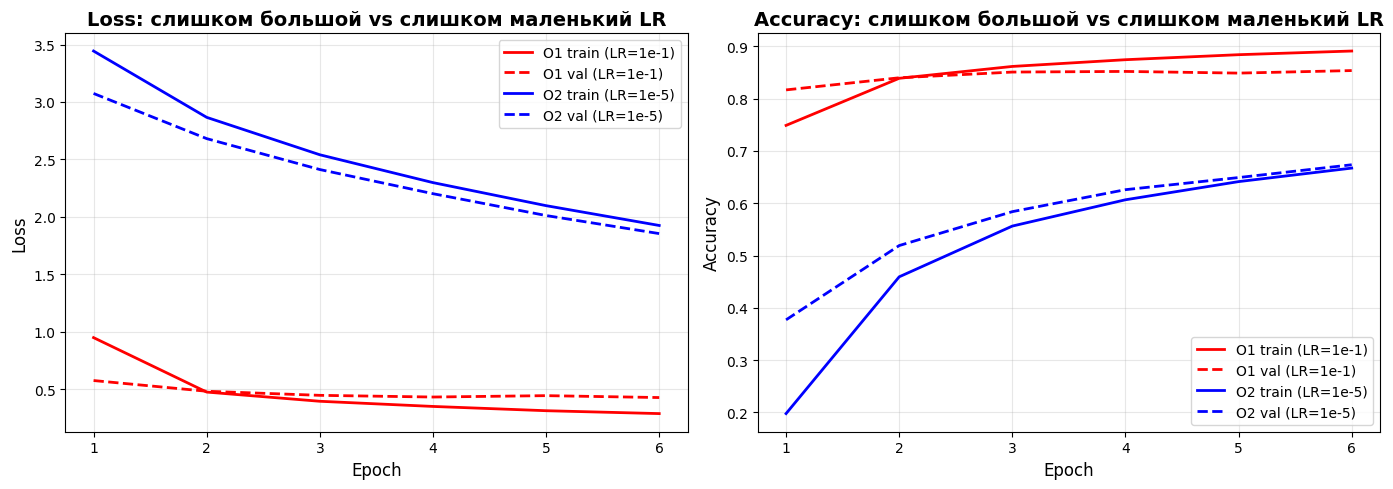

 График сохранен: artifacts/figures/curves_lr_extremes.png


In [31]:
print("ГРАФИК ДИАГНОСТИКИ LEARNING RATE (O1 vs O2)")

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#  ГРАФИК LOSS (сравнение O1 и O2) 
ax1.plot(range(1, len(history_o1['train_loss'])+1), history_o1['train_loss'], 
         'r-', linewidth=2, label='O1 train (LR=1e-1)')
ax1.plot(range(1, len(history_o1['val_loss'])+1), history_o1['val_loss'], 
         'r--', linewidth=2, label='O1 val (LR=1e-1)')
ax1.plot(range(1, len(history_o2['train_loss'])+1), history_o2['train_loss'], 
         'b-', linewidth=2, label='O2 train (LR=1e-5)')
ax1.plot(range(1, len(history_o2['val_loss'])+1), history_o2['val_loss'], 
         'b--', linewidth=2, label='O2 val (LR=1e-5)')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss: слишком большой vs слишком маленький LR', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ===== ГРАФИК ACCURACY (сравнение O1 и O2) =====
ax2.plot(range(1, len(history_o1['train_acc'])+1), history_o1['train_acc'], 
         'r-', linewidth=2, label='O1 train (LR=1e-1)')
ax2.plot(range(1, len(history_o1['val_acc'])+1), history_o1['val_acc'], 
         'r--', linewidth=2, label='O1 val (LR=1e-1)')
ax2.plot(range(1, len(history_o2['train_acc'])+1), history_o2['train_acc'], 
         'b-', linewidth=2, label='O2 train (LR=1e-5)')
ax2.plot(range(1, len(history_o2['val_acc'])+1), history_o2['val_acc'], 
         'b--', linewidth=2, label='O2 val (LR=1e-5)')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy: слишком большой vs слишком маленький LR', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{figures_dir}/curves_lr_extremes.png", dpi=150, bbox_inches='tight')
plt.show()
print(f" График сохранен: {figures_dir}/curves_lr_extremes.png")